## Step (1) EDA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv("telecommunications_churn.csv")
df

,account_length,voice_mail_plan,voice_mail_messages,day_mins,evening_mins,night_mins,international_mins,customer_service_calls,international_plan,day_calls,day_charge,evening_calls,evening_charge,night_calls,night_charge,international_calls,international_charge,total_charge,churn
0,128,1,25,265.1,197.4,244.7,10.0,1,0,110,45.07,99,16.78,91,11.01,3,2.70,75.56,0
1,107,1,26,161.6,195.5,254.4,13.7,1,0,123,27.47,103,16.62,103,11.45,3,3.70,59.24,0
2,137,0,0,243.4,121.2,162.6,12.2,0,0,114,41.38,110,10.30,104,7.32,5,3.29,62.29,0
3,84,0,0,299.4,61.9,196.9,6.6,2,1,71,50.90,88,5.26,89,8.86,7,1.78,66.80,0
4,75,0,0,166.7,148.3,186.9,10.1,3,1,113,28.34,122,12.61,121,8.41,3,2.73,52.09,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,192,1,36,156.2,215.5,279.1,9.9,2,0,77,26.55,126,18.32,83,12.56,6,2.67,60.10,0
3329,68,0,0,231.1,153.4,191.3,9.6,3,0,57,39.29,55,13.04,123,8.61,4,2.59,63.53,0
3330,28,0,0,180.8,288.8,191.9,14.1,2,0,109,30.74,58,24.55,91,8.64,6,3.81,67.74,0
3331,184,0,0,213.8,159.6,139.2,5.0,2,1,105,36.35,84,13.57,137,6.26,10,1.35,57.53,0


In [4]:
print(df['churn'].unique())

[0 1]


In [5]:
print("The size of data:", df.size)
print("The number of rows and columns:", df.shape)
print("The Data type:", df.dtypes)

The size of data: 63327
The number of rows and columns: (3333, 19)
The Data type: account_length              int64
voice_mail_plan             int64
voice_mail_messages         int64
day_mins                  float64
evening_mins              float64
night_mins                float64
international_mins        float64
customer_service_calls      int64
international_plan          int64
day_calls                   int64
day_charge                float64
evening_calls               int64
evening_charge            float64
night_calls                 int64
night_charge              float64
international_calls         int64
international_charge      float64
total_charge              float64
churn                       int64
dtype: object


In [6]:
df.isnull().sum()

account_length            0
voice_mail_plan           0
voice_mail_messages       0
day_mins                  0
evening_mins              0
night_mins                0
international_mins        0
customer_service_calls    0
international_plan        0
day_calls                 0
day_charge                0
evening_calls             0
evening_charge            0
night_calls               0
night_charge              0
international_calls       0
international_charge      0
total_charge              0
churn                     0
dtype: int64

In [7]:
# Count of churn vs non-churn
chrun_counts = df['churn'].value_counts()
print(chrun_counts)

churn
0    2850
1     483
Name: count, dtype: int64


In [8]:
# Percentage distribution
churn_percentage = df['churn'].value_counts(normalize=True) * 100
print(churn_percentage)

churn
0    85.508551
1    14.491449
Name: proportion, dtype: float64


In [9]:
summary=df.describe().T
summary

,count,mean,std,min,25%,50%,75%,max
account_length,3333.0,101.064806,39.822106,1.00,74.00,101.00,127.00,243.00
voice_mail_plan,3333.0,0.276628,0.447398,0.00,0.00,0.00,1.00,1.00
voice_mail_messages,3333.0,8.099010,13.688365,0.00,0.00,0.00,20.00,51.00
day_mins,3333.0,179.775098,54.467389,0.00,143.70,179.40,216.40,350.80
evening_mins,3333.0,200.980348,50.713844,0.00,166.60,201.40,235.30,363.70
night_mins,3333.0,200.872037,50.573847,23.20,167.00,201.20,235.30,395.00
international_mins,3333.0,10.237294,2.791840,0.00,8.50,10.30,12.10,20.00
customer_service_calls,3333.0,1.562856,1.315491,0.00,1.00,1.00,2.00,9.00
international_plan,3333.0,0.096910,0.295879,0.00,0.00,0.00,0.00,1.00
day_calls,3333.0,100.435644,20.069084,0.00,87.00,101.00,114.00,165.00


In [10]:
X = df.drop('churn', axis=1)
y = df['churn']

In [11]:
X['voice_mail_plan'] = X['voice_mail_plan'].astype('category')
X['international_plan'] = X['international_plan'].astype('category')

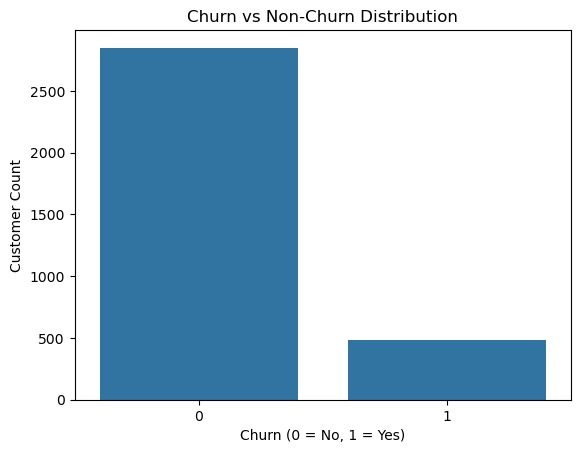

In [12]:
# Churn VS Non-Churn

sns.countplot(x='churn', data=df)
plt.title("Churn vs Non-Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Customer Count")
plt.show()

- More customers stayed than left
  
- Dataset is imbalanced
  
- Churn customers are fewer but important

Accuracy alone is not enough; recall and F1-score are important.

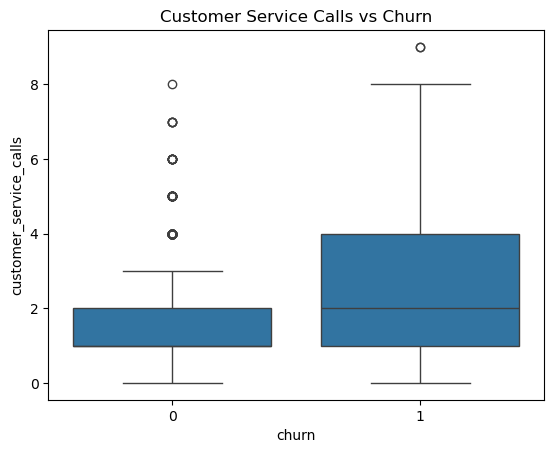

In [13]:
# Customer Service Calls vs Churn

sns.boxplot(x='churn', y='customer_service_calls', data=df)
plt.title("Customer Service Calls vs Churn")
plt.show()

- Customers who churned made more service calls.
  
- Frequent complaints indicate dissatisfaction.

More customer service calls → higher chance of churn

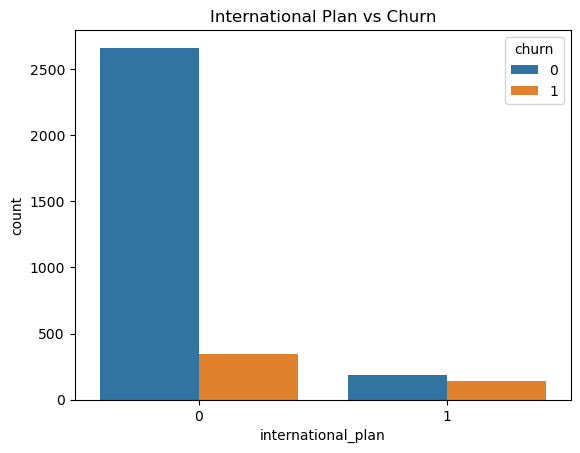

In [14]:
# International Plan vs Churn

sns.countplot(x='international_plan', hue='churn', data=df)
plt.title("International Plan vs Churn")
plt.show()

- Customers with international plans churn more

- Possible reason: higher cost or unmet expectations

International plan users have higher churn tendency


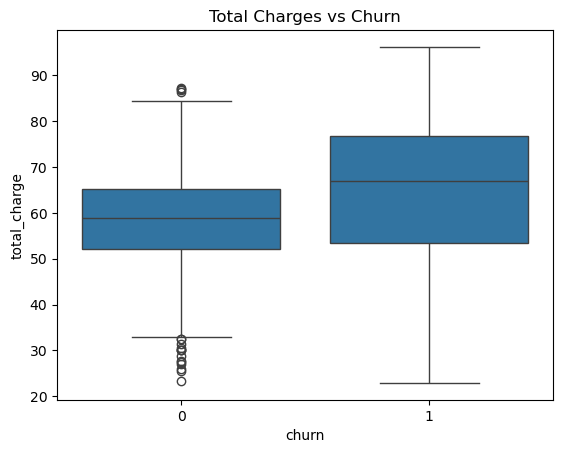

In [15]:
# Total Charges vs Churn

sns.boxplot(x='churn', y='total_charge', data=df)
plt.title("Total Charges vs Churn")
plt.show()

- Churned customers have higher total charges.

- High bills increase customer dissatisfaction.

Higher charges → higher churn risk

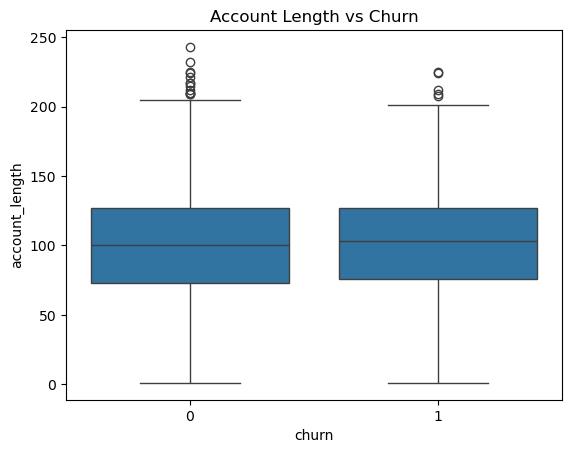

In [16]:
# Account Length vs Churn

sns.boxplot(x='churn', y='account_length', data=df)
plt.title("Account Length vs Churn")
plt.show()

- New customers churn more
  
- Long-term customers are more loyal


Customer loyalty increases with account length.

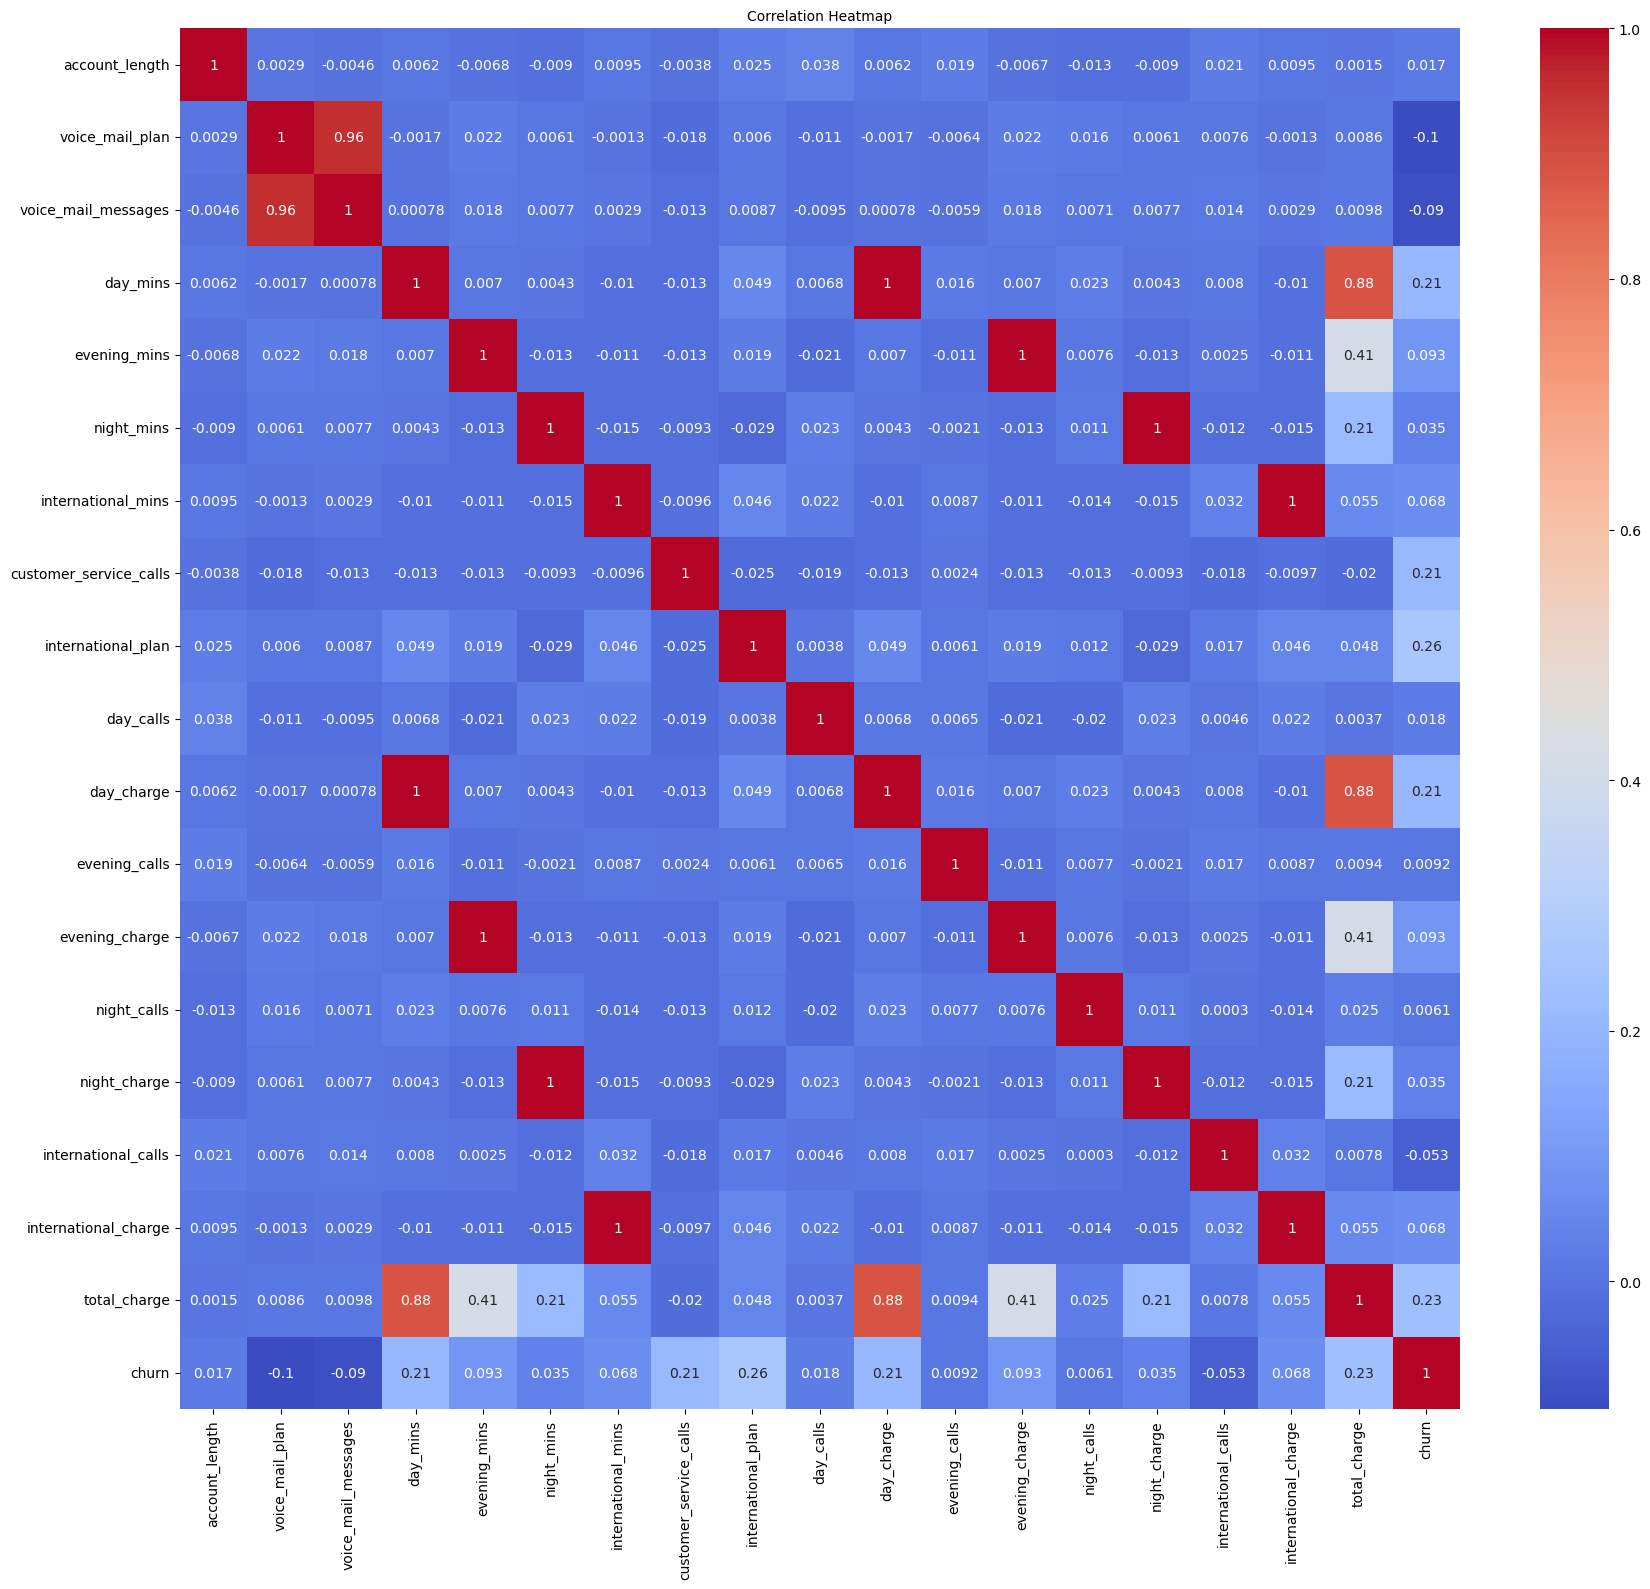

In [17]:
# Correlation Heatmap

plt.figure(figsize=(18,16))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True, cbar=True)
plt.title("Correlation Heatmap", fontsize=10)
plt.tight_layout()
plt.show()

Strong correlation between minutes and charges.

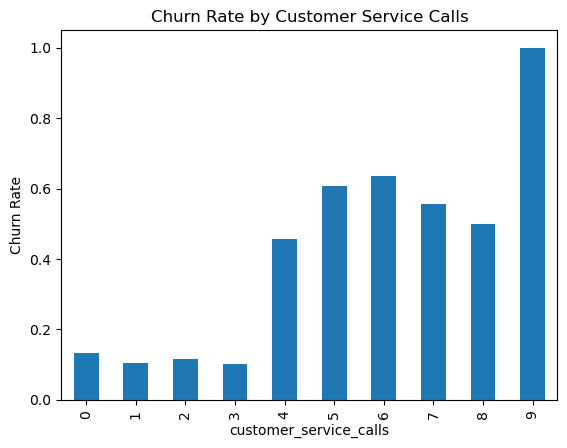

In [18]:
# Churn Rate by Customer Service Calls

churn_rate = df.groupby('customer_service_calls')['churn'].mean()
churn_rate.plot(kind='bar')
plt.title("Churn Rate by Customer Service Calls")
plt.ylabel("Churn Rate")
plt.show()

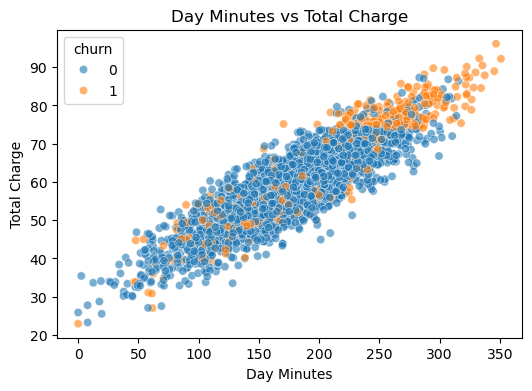

In [19]:
# Scatter Plot
# Day Minutes vs Total Charge

plt.figure(figsize=(6,4))
sns.scatterplot( x='day_mins', y='total_charge',hue='churn', data = df, alpha=0.6)
plt.title('Day Minutes vs Total Charge')
plt.xlabel("Day Minutes")
plt.ylabel("Total Charge")
plt.show()                 

Charges are derived from usage

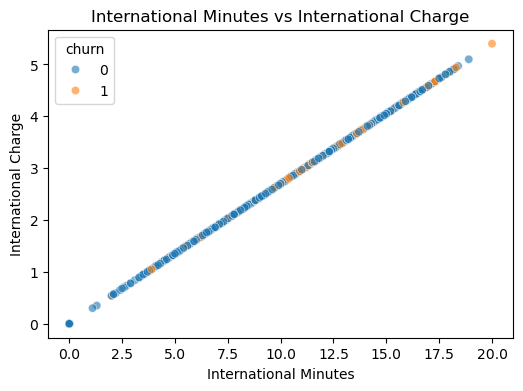

In [20]:
# International Minutes vs International Charge

plt.figure(figsize=(6,4))
sns.scatterplot(
    x='international_mins',
    y='international_charge',
    hue='churn',
    data=df,
    alpha=0.6
)
plt.title("International Minutes vs International Charge")
plt.xlabel("International Minutes")
plt.ylabel("International Charge")
plt.show()

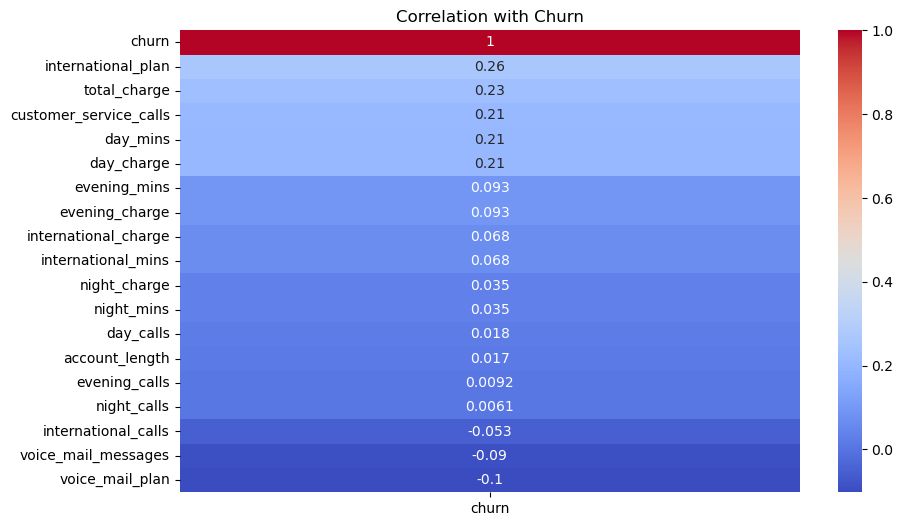

In [21]:
# Check Correlation with Target
plt.figure(figsize=(10,6))
sns.heatmap(df.corr()[['churn']].sort_values(by='churn', ascending=False),
            annot=True, cmap='coolwarm')
plt.title("Correlation with Churn")
plt.show()

In [63]:
def count_outliers(data):
    outlier_count = {}
    for col in data.select_dtypes(include=['int64','float64']).columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = data[(data[col] < lower) | (data[col] > upper)]
        outlier_count[col] = outliers.shape[0]
    
    return outlier_count

outliers = count_outliers(df)
for col, count in outliers.items():
    print(f"{col} : {count}")

account_length : 18
voice_mail_plan : 0
voice_mail_messages : 1
day_mins : 25
evening_mins : 24
night_mins : 30
international_mins : 46
customer_service_calls : 267
international_plan : 323
day_calls : 23
day_charge : 25
evening_calls : 20
evening_charge : 24
night_calls : 22
night_charge : 30
international_calls : 78
international_charge : 49
total_charge : 27
churn : 483


In [64]:
total_outliers = sum(outliers.values())
print("Total Outliers:", total_outliers)

Total Outliers: 1515


In [65]:
# Capping (Handling Outliers)

def cap_outliers(data):
    for col in data.select_dtypes(include=['int64','float64']).columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        data[col] = np.where(data[col] < lower, lower,
                             np.where(data[col] > upper, upper,
                                      data[col]))
    return data

df = cap_outliers(df)

In [66]:
new_outliers = count_outliers(df)
for col, count in new_outliers.items():
    print(f"{col} : {count}")

account_length : 0
voice_mail_plan : 0
voice_mail_messages : 0
day_mins : 0
evening_mins : 0
night_mins : 0
international_mins : 0
customer_service_calls : 0
international_plan : 0
day_calls : 0
day_charge : 0
evening_calls : 0
evening_charge : 0
night_calls : 0
night_charge : 0
international_calls : 0
international_charge : 0
total_charge : 0
churn : 0


In [22]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [23]:
print(df['churn'].value_counts())
print(y_train.value_counts())

churn
0    2850
1     483
Name: count, dtype: int64
churn
0    2280
1     386
Name: count, dtype: int64


In [24]:
# Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

StandardScaler:

Converts mean = 0

Standard deviation = 1

## Step 2) Model Building

## MODEL 1: Logistic Regression

In [25]:
from sklearn.linear_model import LogisticRegression

In [26]:
# create model

log_model = LogisticRegression(class_weight='balanced', max_iter=1000,random_state=42)

In [27]:
# Train model

log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
print(X_train_scaled.shape)
print(y_train.shape)

(2666, 18)
(2666,)


In [29]:
# Save Model

import joblib
joblib.dump(log_model, "logistic_model.pkl")

['logistic_model.pkl']

## MODEL 2: Decision Tree

Captures non-linear relationships

Easy to interpret

Helps understand decision rules

Works well for structured data

In [30]:
from sklearn.tree import DecisionTreeClassifier

In [31]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

In [32]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [33]:
import joblib
joblib.dump(dt_model, "decision_tree_model.pkl")

['decision_tree_model.pkl']

## MODEL 3: Random Forest

Ensemble of multiple trees

Reduces overfitting

More stable than Decision Tree

Often performs better

In [34]:
from sklearn.ensemble import RandomForestClassifier

In [35]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

In [36]:
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
joblib.dump(rf_model, "random_forest_model.pkl")

['random_forest_model.pkl']

## MODEL 4: XGBoost

Boosting algorithm

High performance

Industry standard for churn problems

Handles complex relationships

In [38]:
from xgboost import XGBClassifier

In [39]:
# Handle imbalance
scale_pos_weight =  len(y_train[y_train==0]) / len(y_train[y_train==1])

In [40]:
# Create XGBoost model

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

In [41]:
# train model
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [42]:
joblib.dump(rf_model, "random_forest_model.pkl")

['random_forest_model.pkl']

## MODEL 5: K-Nearest Neighbors (KNN)

Distance-based model

Simple but powerful

Good for comparison

Works well after scaling

In [43]:
from sklearn.neighbors import KNeighborsClassifier

In [44]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [45]:
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [46]:
joblib.dump(knn_model, "knn_model.pkl")

['knn_model.pkl']

## MODEL 6: Support Vector Machine (SVM)

Powerful for classification

Finds optimal separating boundary

Good for complex data

In [47]:
from sklearn.svm import SVC

In [48]:
svm_model = SVC(
    kernel='linear',
    class_weight='balanced',
    probability=True,
    random_state=42
)

In [49]:
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [50]:
joblib.dump(svm_model, "svm_model.pkl")

['svm_model.pkl']

## Model 7: AdaBoost

Boosting technique

Combines weak learners

Improves performance

In [51]:
from sklearn.ensemble import AdaBoostClassifier

In [52]:
ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

In [53]:
ada_model.fit(X_train, y_train)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [54]:
joblib.dump(ada_model, "adaboost_model.pkl")

['adaboost_model.pkl']

## Deep Learning Model

Model 1: Artificial Neural Network (ANN)

In [55]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [56]:
X_train_nn = X_train_scaled
X_test_nn = X_test_scaled

In [57]:
# Build Neural Network Model

ann_model = Sequential()

# Input layer + Hidden layer
ann_model.add(Dense(32, activation='relu', input_dim=X_train_nn.shape[1]))

# Second hidden layer
ann_model.add(Dense(16, activation='relu'))

# Output layer
ann_model.add(Dense(1, activation='sigmoid'))


c:\Users\lenovo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
# Compile model

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [59]:
# train model

ann_model.fit(
    X_train_nn,
    y_train,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8162 - loss: 0.4635
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8672 - loss: 0.3466
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8830 - loss: 0.3080
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8950 - loss: 0.2787
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9066 - loss: 0.2567
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9167 - loss: 0.2396
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9216 - loss: 0.2297
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9269 - loss: 0.2204
Epoch 9/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9295 - loss: 0.2149
Epoch 10/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9306 - loss: 0.2094
Epoch 11/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9366 - loss: 0.2046
Epoch 12/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9377 - lo

In [60]:
# Save model

ann_model.save("ann_churn_model.h5")